In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate(grad_fn, V_fn, x0=2.0, y0=2.0, lr=0.1, iters=50):
    x, y = x0, y0
    xs, ys, vs = [x], [y], [V_fn(x, y)]
    for t in range(iters):
        gx, gy = grad_fn(x, y)
        x = x - lr * gx
        y = y + lr * gy
        xs.append(x); ys.append(y); vs.append(V_fn(x, y))
    return np.array(xs), np.array(ys), np.array(vs)

grad_quad = lambda x, y: (2*x + y, -2*y + x)
V_quad    = lambda x, y: x**2 - y**2 + x*y

x1, y1, v1 = simulate(grad_quad, V_quad)
print("Final (x, y, V):", x1[-1], y1[-1], v1[-1])


Final (x, y, V): 4.4719690800443964e-05 3.921924499295701e-05 2.2155740769816266e-09


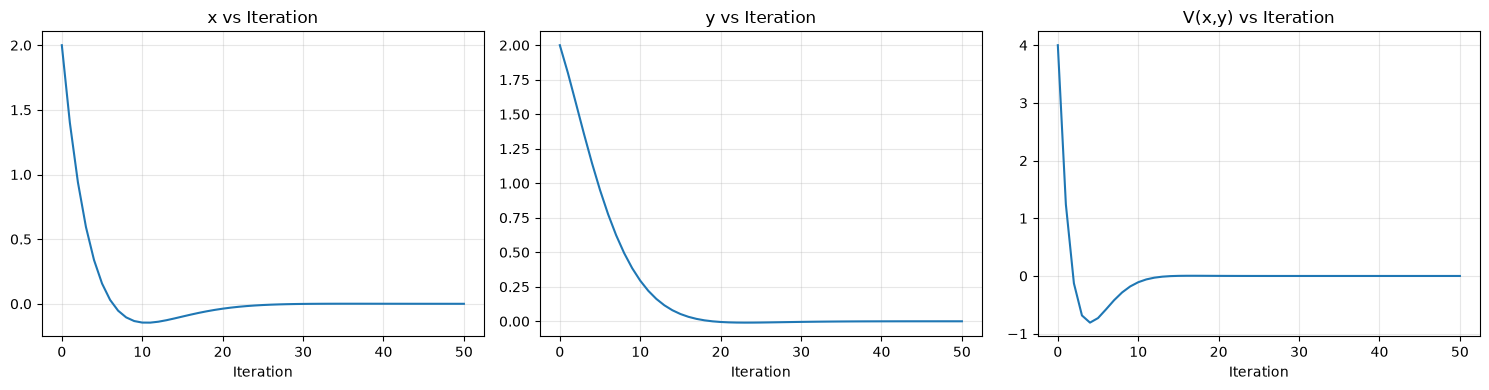

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x1); axes[0].set_title('x vs Iteration'); axes[0].set_xlabel('Iteration'); axes[0].grid(alpha=0.3)
axes[1].plot(y1); axes[1].set_title('y vs Iteration'); axes[1].set_xlabel('Iteration'); axes[1].grid(alpha=0.3)
axes[2].plot(v1); axes[2].set_title('V(x,y) vs Iteration'); axes[2].set_xlabel('Iteration'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


Final (x, y, V): 3.1579352435423136 -1.7845166214816859 -5.6353879316640745


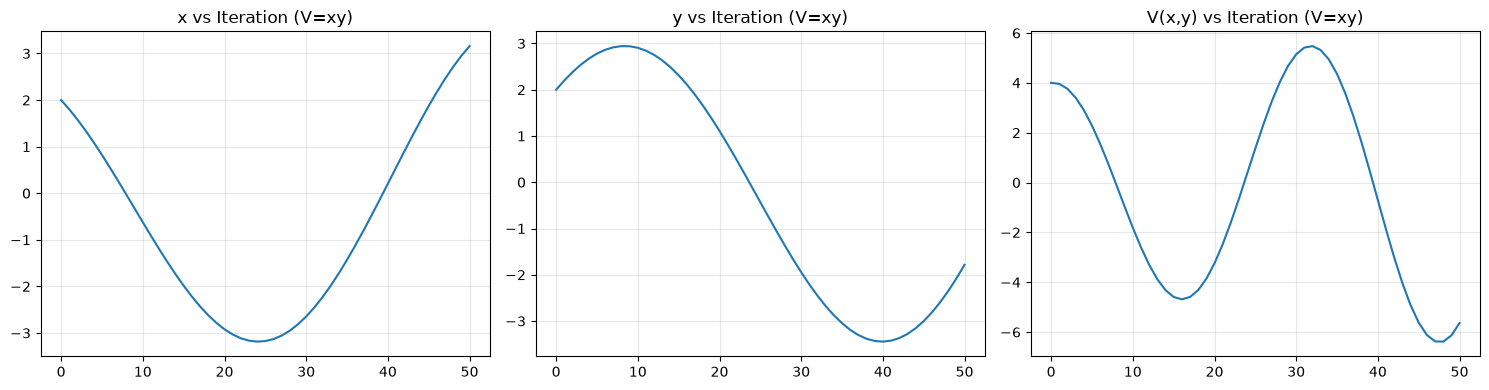

In [ ]:
grad_bilinear = lambda x, y: (y, x)
V_bilinear    = lambda x, y: x * y

x2, y2, v2 = simulate(grad_bilinear, V_bilinear)
print("Final (x, y, V):", x2[-1], y2[-1], v2[-1])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(x2); axes[0].set_title('x vs Iteration (V=xy)'); axes[0].grid(alpha=0.3)
axes[1].plot(y2); axes[1].set_title('y vs Iteration (V=xy)'); axes[1].grid(alpha=0.3)
axes[2].plot(v2); axes[2].set_title('V(x,y) vs Iteration (V=xy)'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


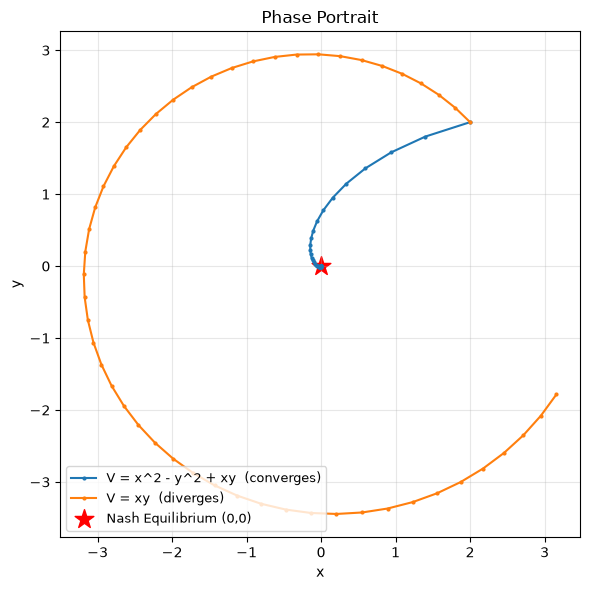

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x1, y1, '-o', ms=2, label='V = x^2 - y^2 + xy  (converges)')
ax.plot(x2, y2, '-o', ms=2, label='V = xy  (diverges)')
ax.scatter([0], [0], c='red', marker='*', s=200, label='Nash Equilibrium (0,0)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Phase Portrait')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
